In [1]:

import zarr
from pathlib import Path

import geopandas as gpd
import pandas as pd

import json
from pathlib import Path

import geopandas as gpd
import os
os.environ["FASTFUELS_API_KEY"] = "test-api-key"

from fastfuels_sdk import (
    Domain,
    Grids,
    Inventories,
    TreeGridBuilder,
)

from shapely.geometry import box
import matplotlib.pyplot as plt
import zipfile

import numpy as np
import copy

# Load Wade's Treelist

In [2]:
# Paths
DATA_DIR = Path("data")
INPUT_GPKG = DATA_DIR / "final_detected_tree_tops.gpkg"

# Load the GeoPackage
print(f"Loading {INPUT_GPKG}...")
trees = gpd.read_file(INPUT_GPKG)
print(f"Loaded {len(trees)} trees")

# Create a GeoDataFrame that is the clipped extent (bounding box) of trees
# minx, miny, maxx, maxy = trees.total_bounds


minx, miny, maxx, maxy = 651498.0000000000000000,4747292.0000000000000000, 652278.0000000000000000,4747810.0000000000000000

detected_treetops_extent = gpd.GeoDataFrame(
    {"name": ["trees_extent"]},
    geometry=[box(minx, miny, maxx, maxy)],
    crs=trees.crs,
)

Loading data/final_detected_tree_tops.gpkg...
Loaded 51242 trees


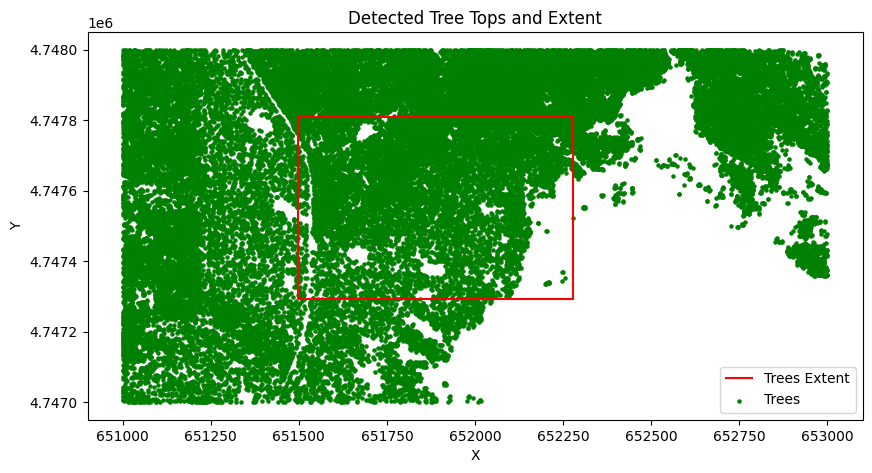

In [3]:
# Plot the trees and their extent
fig, ax = plt.subplots(figsize=(10, 10))
detected_treetops_extent.boundary.plot(ax=ax, color="red", label="Trees Extent")
trees.plot(ax=ax, color="green", markersize=5, label="Trees")
ax.set_title("Detected Tree Tops and Extent")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.legend()
plt.show()

# FastFuels

### Prep Wade's Treelist for FastFuels

In [4]:
output_file_name = DATA_DIR / "trees_for_fastfuels_upload.csv"
output = pd.DataFrame({
    "SPCD": 122,  # Ponderosa Pine for all trees
    "STATUSCD": 1,  # All live
    "DIA": trees["dbh_cm"].values,
    "HT": trees["tree_height_m"].values,
    "CR": (trees["crown_length_m"] / trees["tree_height_m"]).values,
    "X": trees.geometry.x.values,
    "Y": trees.geometry.y.values,
    "CROWN_FUEL_LOAD": trees["cruz_crown_biomass_kg"].values,
    "MAX_CROWN_RADIUS": (trees["crown_dia_m"] / 2).values,
})

# Clamp CR to [0, 1] range
output["CR"] = output["CR"].clip(0, 1)

# Drop rows with NaN in required columns
required = ["SPCD", "STATUSCD", "DIA", "HT", "CR", "X", "Y", "CROWN_FUEL_LOAD", "MAX_CROWN_RADIUS"]
before = len(output)
output = output.dropna(subset=required)
after = len(output)
if before != after:
    print(f"Dropped {before - after} rows with NaN values")

print(f"Output: {len(output)} trees")
print(f"Columns: {list(output.columns)}")
print(f"\nSample:\n{output.head()}")
print(f"\nSummary:\n{output.describe()}")

# Save to CSV
output.to_csv(output_file_name, index=False)
print(f"\nSaved to {output_file_name}")

Output: 51242 trees
Columns: ['SPCD', 'STATUSCD', 'DIA', 'HT', 'CR', 'X', 'Y', 'CROWN_FUEL_LOAD', 'MAX_CROWN_RADIUS']

Sample:
   SPCD  STATUSCD        DIA     HT        CR           X            Y  \
0   122         1  15.558223   9.35  0.625107  651000.125  4747999.875   
1   122         1  10.337119   6.55  0.515733  651018.625  4747999.875   
2   122         1  21.345815  12.07  0.875725  651034.625  4747999.875   
3   122         1  15.447166   9.32  0.643987  651035.875  4747999.875   
4   122         1  19.522790  11.32  0.694452  651072.625  4747999.875   

   CROWN_FUEL_LOAD  MAX_CROWN_RADIUS  
0        14.175397          1.074185  
1         3.338541          0.732904  
2         3.887113          0.661571  
3         0.902952          0.423142  
4         9.865383          1.007280  

Summary:
          SPCD  STATUSCD           DIA            HT            CR  \
count  51242.0   51242.0  51242.000000  51242.000000  51242.000000   
mean     122.0       1.0     20.869158     1

### Run FastFuels for Wade's Treelist

In [48]:
import os

os.environ["FASTFUELS_API_KEY"] = "test-api-key"

TREELIST_CSV = DATA_DIR / "trees_for_fastfuels_upload.csv"

# ── Domain ───────────────────────────────────────────────────────────────────
print("Creating domain...")
domain = Domain.from_geodataframe(
    geodataframe=detected_treetops_extent,
    name="sycan-fuels-initiative",
    description="Sycan fuels initiative site with custom crown fuel load and crown radius",
    horizontal_resolution=2.0,
    vertical_resolution=1.0,
)
domain_id = domain.id
print(f"Domain: {domain.name} ({domain_id})")

# ── Tree Inventory ───────────────────────────────────────────────────────────
print(f"\nUploading tree inventory from {TREELIST_CSV}...")
tree_inventory = Inventories.from_domain_id(domain_id).create_tree_inventory_from_file_upload(
    TREELIST_CSV
)
tree_inventory = tree_inventory.wait_until_completed(verbose=False)
print(f"Tree inventory status: {tree_inventory.status}")

# ── Tree Inventory Export ────────────────────────────────────────────────────
print("\nExporting FastFuels Trees to geojson...")
tree_inventory_export = tree_inventory.create_export("geojson")
tree_inventory_export = tree_inventory_export.wait_until_completed(verbose=False, in_place=True)
tree_inventory_export.to_file("data/fastfuels_tree_inventory.geojson")
print(f"Exported tree inventory to data/fastfuels_tree_inventory.geojson")

# ── Tree Grid ────────────────────────────────────────────────────────────────
print("\nBuilding tree grid...")
tree_grid = (
    TreeGridBuilder(domain_id=domain_id)
    .with_bulk_density_from_tree_inventory()
    .with_spcd_from_tree_inventory()
    .build()
)
tree_grid = tree_grid.wait_until_completed(verbose=False, in_place=True)
print(f"Tree grid status: {tree_grid.status}")

# ── Grid Export ───────────────────────────────────────────────────────────────
print("\nExporting grids to zarr...")
grid_export = Grids.from_domain_id(domain_id).create_export("zarr")
grid_export = grid_export.wait_until_completed(verbose=False, in_place=True)

# Save the data
output_path = DATA_DIR / "canopy_fuel_grid.zip"
grid_export.to_file(str(output_path))
print(f"\nExported to {output_path}")


Creating domain...
Domain: sycan-fuels-initiative (f6a3226927774cf095f179b4d0389d9a)

Uploading tree inventory from data/trees_for_fastfuels_upload.csv...
Tree inventory status: JobStatus.COMPLETED

Exporting FastFuels Trees to geojson...
Exported tree inventory to data/fastfuels_tree_inventory.geojson

Building tree grid...
Tree grid status: JobStatus.COMPLETED

Exporting grids to zarr...

Exported to data/canopy_fuel_grid.zip


### Look at the FastFuels data

In [6]:
# Unzip the exported zarr file
with zipfile.ZipFile(DATA_DIR / "canopy_fuel_grid.zip", "r") as zip_ref:
    zip_ref.extractall(DATA_DIR / "canopy_fuel_grid")

In [7]:
zroot = zarr.open(DATA_DIR / "canopy_fuel_grid", mode="r")
ff_voxelized_tree_data = zroot["tree"]
ff_voxelized_tree_data_bulk_density = ff_voxelized_tree_data["bulkDensity"]
ff_voxelized_tree_data_bulk_density

<Array file://data/canopy_fuel_grid/tree/bulkDensity shape=(35, 259, 390) dtype=float32>

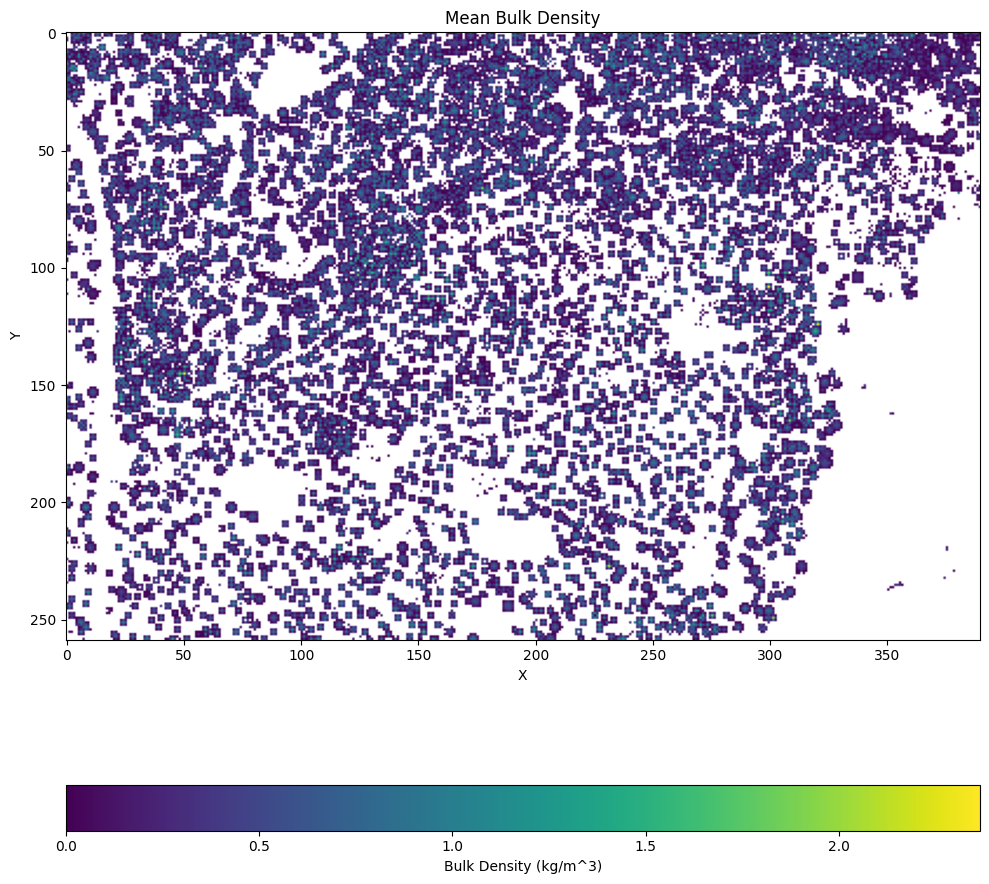

In [8]:
# Plot the bulk density grid summed across the z-axis
data = ff_voxelized_tree_data_bulk_density[...]
masked_data = np.ma.masked_equal(data, 0) # Mask all zeros

current_cmap = copy.copy(plt.cm.viridis)
current_cmap.set_bad(color='white')


fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(masked_data.mean(axis=0), cmap=current_cmap)
ax.set_title("Mean Bulk Density")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()

# LANL TREES

### Run LANL TREES

In [26]:
! ./trees.exe

  Running TREES to generate fuel     
  files for FIRETEC or QUIC-Fire     
           0
                                                                                                                                                                                                                                                                
  
 fuellist
 Number of Set Species =            1
 Groups =            1
 Number of Trees in each Species =        11236
           1
 Not using target topo
 cell           1 bottom height   0.00000000    
 cell           2 bottom height  0.100734696    
 cell           3 bottom height  0.205877557    
 cell           4 bottom height  0.319836736    
 cell           5 bottom height  0.447020411    
 cell           6 bottom height  0.591836751    
 cell           7 bottom height  0.758693874    
 cell           8 bottom height  0.951999962    
 cell           9 bottom height   1.17616320    
 cell          10 bottom height   1.43559182    
 cell 

### Look at LANL TREES data

In [27]:
tl = pd.read_csv('Cloud2Trees_TreeList.txt', sep=' ', header = None)

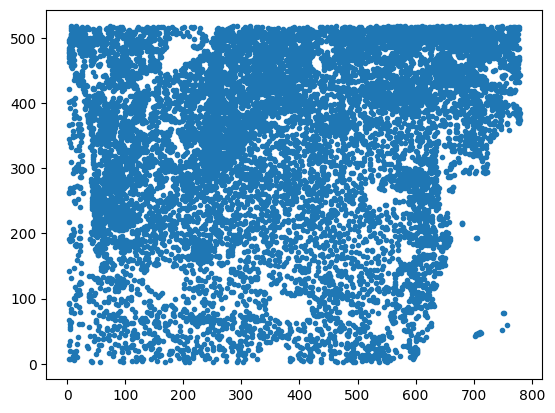

In [28]:
plt.scatter(tl[[1]], tl[[2]], marker = '.')

In [29]:
from scipy.io import FortranFile 

def read_dat_file(filename, nz, ny, nx, order= "C"):
    """
    Read in a .dat file as a numpy array.

    Parameters
    ----------
    filename : Path or str
        The path to the .dat file to read.
    nz : int
        The number of cells in the z-direction.
    ny : int
        The number of cells in the y-direction.
    nx : int
        The number of cells in the x-direction.
    order : str, optional
        The order of the array. Default is "C".

    Returns
    -------
    ndarray
        A 3D numpy array representing the data in the .dat file. The array
        has dimensions (nz, ny, nx).
    """
    if isinstance(filename, str):
        filename = (filename)

    with open(filename, "rb") as fin:
        arr = (
            FortranFile(fin)
            .read_reals(dtype="float32")
            .reshape((nz, ny, nx), order=order)
        )

    return arr

In [30]:
lanl_trees_voxelized = read_dat_file('/home/jovyan/work/agu_2025/lanl_trees_fastfuels_comparison/sycan_marsh/treesrhof.dat',
                                     35, 259, 390)

# lanl_trees_voxelized = read_dat_file('/home/jovyan/work/agu_2025/lanl_trees_fastfuels_comparison/sycan_marsh/treesrhof.dat',
#                                      71, 500, 1000)

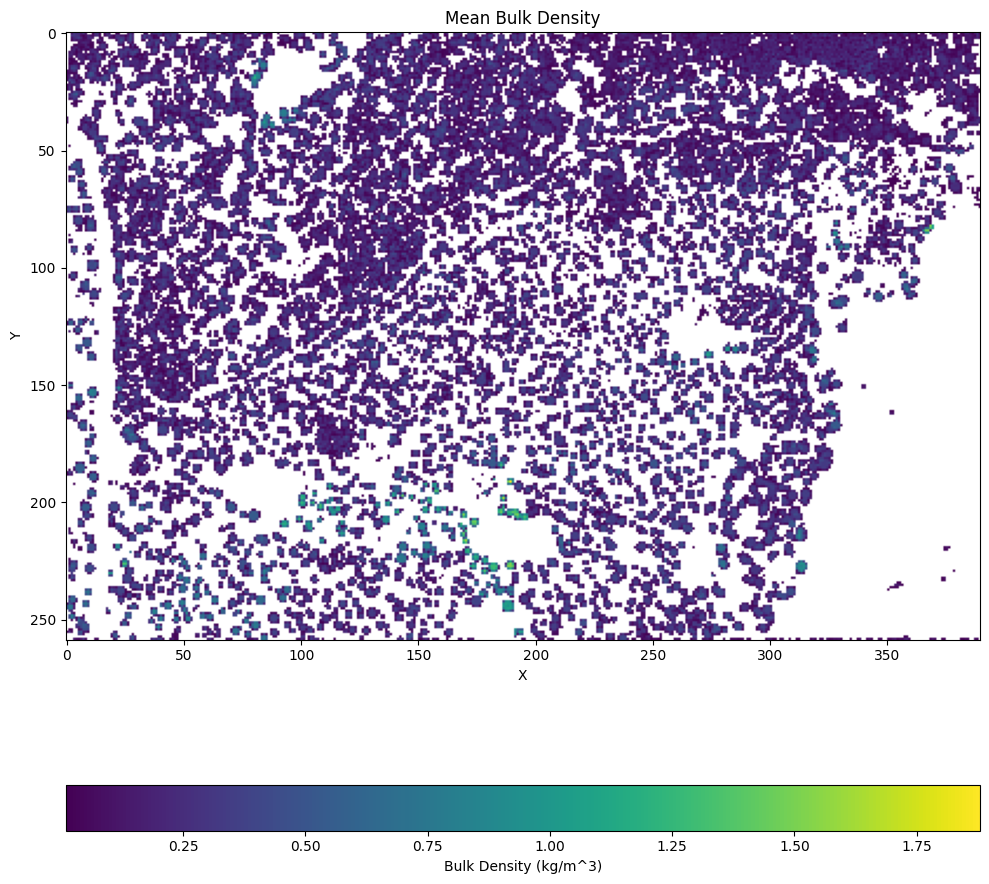

In [42]:
# Plot the bulk density grid summed across the z-axis
data = lanl_trees_voxelized
masked_data = np.ma.masked_where(data <= 0.01, data) # Mask all zeros

# masked_data = np.flipud(masked_data)

current_cmap = copy.copy(plt.cm.viridis)
current_cmap.set_bad(color='white')


fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(np.flipud(masked_data.mean(axis=0)), cmap=current_cmap)
ax.set_title("Mean Bulk Density")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()

# Compare Outputs

In [32]:
# differences in the two 
diff = ff_voxelized_tree_data_bulk_density[...].sum(axis=0) - np.flipud(lanl_trees_voxelized.sum(axis=0))


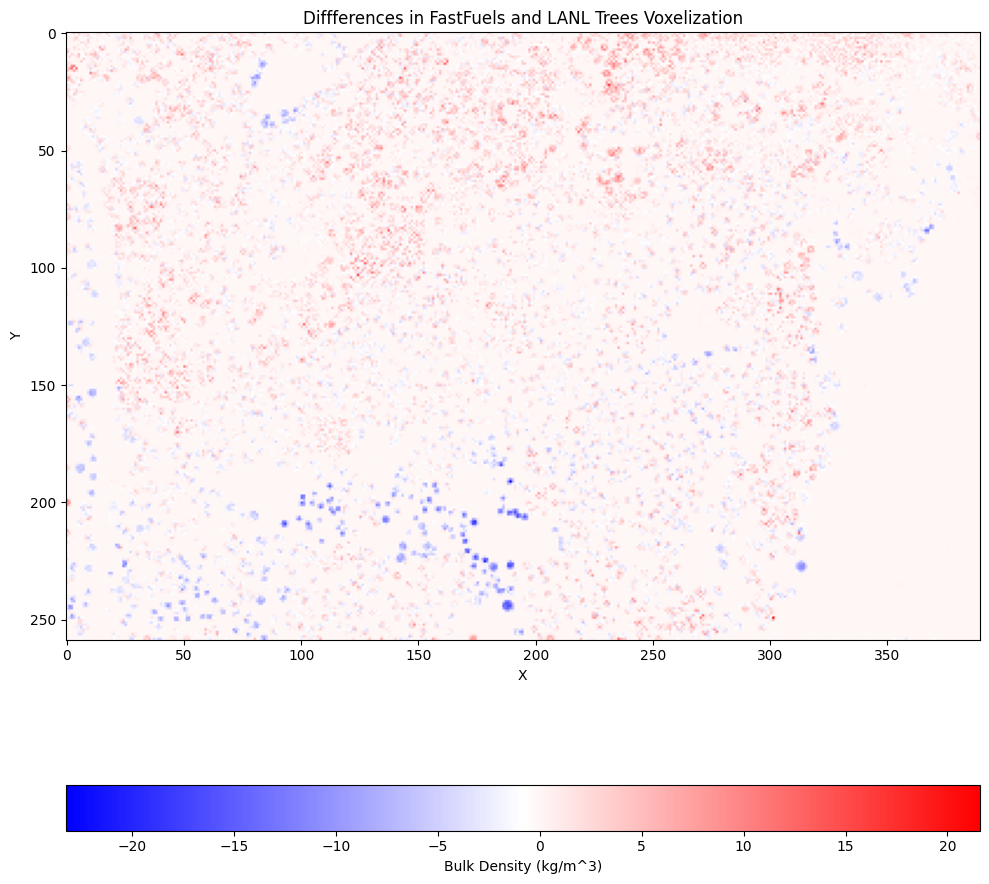

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(diff, cmap='bwr')
ax.set_title("Diffferences in FastFuels and LANL Trees Voxelization")
ax.set_xlabel("X")
ax.set_ylabel("Y")
fig.colorbar(im, ax=ax, label="Bulk Density (kg/m^3)", orientation="horizontal")
plt.tight_layout()
plt.show()

Red is where Fastfuels shows a higher bulk density, blue is where LANL Trees has a higher bulk density

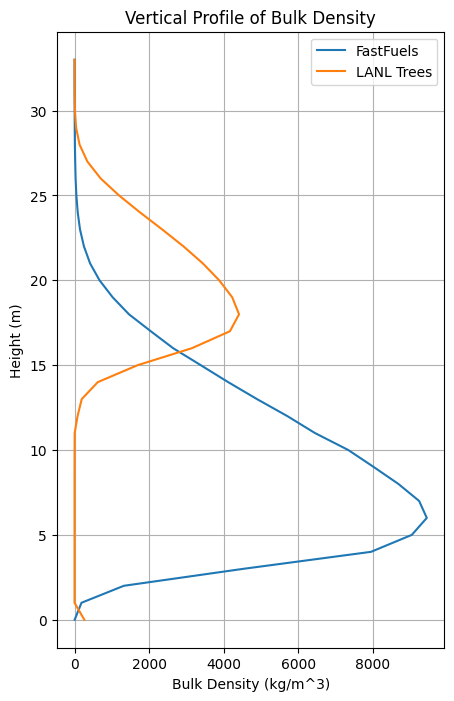

In [46]:
# Sum across the last two axes (rows and columns) to get 1 value per height layer
profile_values_ff = ff_voxelized_tree_data_bulk_density[...][1:,:,:].sum(axis=(1, 2)) 
profile_values_lanl = lanl_trees_voxelized[1:,:,:].sum(axis=(1, 2)) 

# Create height indices
heights = np.arange(profile_values_ff.shape[0])

# Plotting
plt.figure(figsize=(5, 8))
plt.plot(profile_values_ff, heights, linestyle='-', label = 'FastFuels')
plt.plot(profile_values_lanl, heights, linestyle='-', label = 'LANL Trees')

# Add labels for clarity
plt.xlabel('Bulk Density (kg/m^3)')
plt.ylabel('Height (m)')
plt.title('Vertical Profile of Bulk Density')
plt.grid(True)
plt.legend()
plt.show()



### Compare total mass

In [49]:
# Read FastFuels grid cell dimensions from zarr attrs
ff_attrs = json.loads((DATA_DIR / "canopy_fuel_grid" / ".zattrs").read_text())
dx, dy, dz = ff_attrs["dx"], ff_attrs["dy"], ff_attrs["dz"]
ff_cell_volume_m3 = dx * dy * dz

print(f"FastFuels cell size: {dx} m x {dy} m x {dz} m  (volume = {ff_cell_volume_m3} m^3)")

# Inventory mass — from the prepared treelist (post-NaN drop, what was uploaded)
ff_inventory_data = gpd.read_file(DATA_DIR / "fastfuels_tree_inventory.geojson")
inventory_mass_kg = float(ff_inventory_data["CROWN_FUEL_LOAD"].sum())

# FastFuels voxel grid mass — bulk density (kg/m^3) * cell volume (m^3)
ff_voxel_mass_kg = float(ff_voxelized_tree_data_bulk_density[...].sum()) * ff_cell_volume_m3

# Comparison
diff = ff_voxel_mass_kg - inventory_mass_kg
pct = 100.0 * diff / inventory_mass_kg

print(f"\nTrees in inventory: {len(ff_inventory_data):,}")
print(f"Inventory mass: {inventory_mass_kg:,.2f} kg")
print(f"FastFuels voxel mass: {ff_voxel_mass_kg:,.2f} kg")
print(f"Difference (FF - inv): {diff:,.2f} kg ({pct:+.4f}%)")


FastFuels cell size: 2.0 m x 2.0 m x 1.0 m  (volume = 4.0 m^3)

Trees in inventory: 11,309
Inventory mass: 398,042.81 kg
FastFuels voxel mass: 396,926.75 kg
Difference (FF - inv): -1,116.06 kg (-0.2804%)


In [53]:
dz, dy, dx = lanl_trees_voxelized.shape

# FastFuels voxel grid mass — bulk density (kg/m^3) * cell volume (m^3)
lanl_voxel_mass_kg = float(lanl_trees_voxelized.sum()) * ff_cell_volume_m3

# Comparison
diff = ff_voxel_mass_kg - lanl_voxel_mass_kg
pct = 100.0 * diff / inventory_mass_kg

print(f"LANL voxel mass: {lanl_voxel_mass_kg:,.2f} kg")
print(f"Difference (FF - LANL): {diff:,.2f} kg ({pct:+.4f}%)")

LANL voxel mass: 393,567.94 kg
Difference (FF - LANL): 3,358.81 kg (+0.8438%)
